# Figure 1 : Rapport entre types de tir et buts

In [47]:
import sys
from pathlib import Path
# Add the folder the project's root to be able to call tidy.py's methods
sys.path.append(str(Path.cwd().parent))

from features.tidy import json2tidy
import pandas as pd
import matplotlib.pyplot as plt

### 📊 Objectifs de la visualisation

L'objectif est de concevoir un graphique mettant en valeur :
* **La répartition des tirs :** le volume de tirs par type pour l'ensemble des équipes au cours d'une saison donnée.
* **L'efficacité offensive :** le nombre de tirs convertis en buts pour chaque catégorie.
* **Le taux de réussite :** le ratio de conversion (rapport buts / tirs) afin d'identifier le type de tir le plus performant.

In [ ]:
# Create a list of the ids of each game by iterating over data folder
# Let's consider the 2022 season for example
season = "2022" 
pathlist = Path(f"../notebooks/data/raw/{season}")
games_id_list = [p.stem for p in pathlist.glob("*.json")]

- Crée le dataframe qui combine les évènements de toutes les parties d'une saison

In [41]:
# Put all the dataframes in a list and merge them into one dataframe
df_games_list = []

for game_id in games_id_list:
    df = json2tidy(f"../notebooks/data/raw/{season}/{game_id}.json")
    df_games_list.append(df)

merged_df_regular = pd.concat(df_games_list, ignore_index=True)
merged_df_regular = merged_df_regular.loc[merged_df_regular["game_type"] == "regular season"]

- Crée un tableau résumé : le nombre de tirs et le nombre de buts pour chaque type de tir
- Les buts sont aussi des tirs, donc le nombre de tirs inclut les buts

In [ ]:
# Copy to avoid pandas warnings when adding a column
merged_df_regular = merged_df_regular.copy()

# Create a boolean column to know if the event is a goal
merged_df_regular["is_goal"] = merged_df_regular["event_type"] == "goal"

# Group by shot type: size counts all the shots (goals included) and sum counts the goals
df_summary = merged_df_regular.groupby("shot_type")["is_goal"].agg(["size", "sum"])
df_summary = df_summary.rename(columns={"size": "shots", "sum": "goals"})

# Percentage of shots that became goals
df_summary["pct"] = df_summary["goals"] / df_summary["shots"] * 100

# Sort by number of shots
df_summary = df_summary.sort_values("shots", ascending=False)

df_summary

,shots,goals,pct
shot_type,,,
wrist,45188,4188,9.267947
snap,13337,1576,11.816750
slap,9445,716,7.580731
backhand,6545,730,11.153552
tip-in,5332,851,15.960240
deflected,1318,223,16.919575
wrap-around,716,57,7.960894
poke,391,58,14.833760
bat,194,47,24.226804


- Crée la figure : les barres rouges (buts) sont superposées aux barres bleues (tirs), avec le pourcentage de buts au-dessus de chaque type

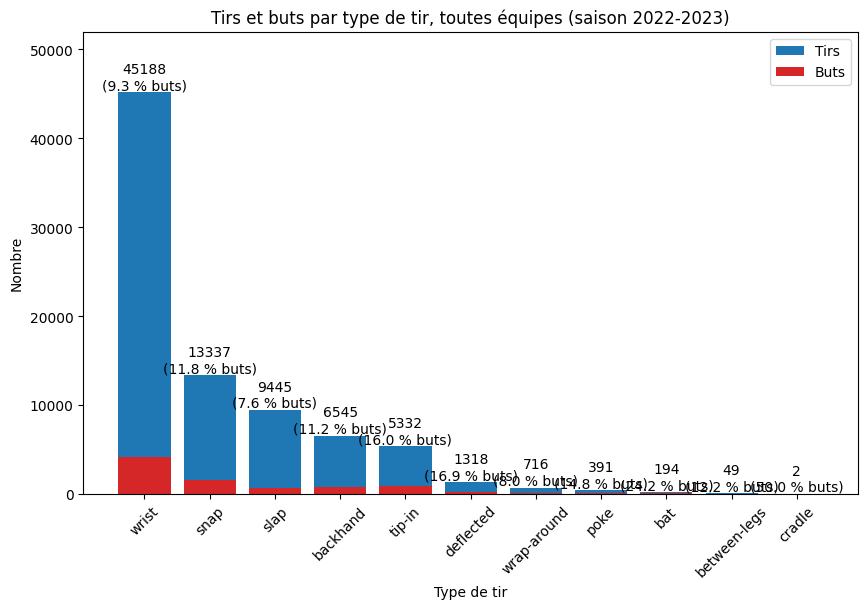

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the shots first (blue), then the goals (red) on top of them
bars_shots = ax.bar(df_summary.index, df_summary["shots"], color="tab:blue", label="Tirs")
bars_goals = ax.bar(df_summary.index, df_summary["goals"], color="tab:red", label="Buts")

# Write the number of shots and the percentage of goals above each blue bar
labels_text = [f"{shots}\n({pct:.1f} % buts)" for shots, pct in zip(df_summary["shots"], df_summary["pct"])]
ax.bar_label(bars_shots, labels=labels_text)

# Add some space at the top so the labels are not cut
ax.set_ylim(0, df_summary["shots"].max() * 1.15)

# Titles and legend
ax.set_title(f"Tirs et buts par type de tir, toutes équipes (saison {season}-{int(season) + 1})")
ax.set_xlabel("Type de tir")
ax.set_ylabel("Nombre")
ax.legend()

# Rotate the names of the shot types if they overlap
ax.tick_params(axis="x", rotation=45)

plt.show()

In [45]:
# Save the figure for the blog post
fig.savefig("shots_by_type.png", dpi=150, bbox_inches="tight")

- Trouve les réponses aux questions à partir du tableau résumé

In [46]:
# Shot type with the highest percentage of goals
most_dangerous = df_summary["pct"].idxmax()
print(f"Type de tir le plus dangereux : {most_dangerous} ({df_summary.loc[most_dangerous, 'pct']:.1f} % de buts sur {df_summary.loc[most_dangerous, 'shots']} tirs)")

# Shot type with the most shots
most_common = df_summary["shots"].idxmax()
print(f"Type de tir le plus courant : {most_common} ({df_summary.loc[most_common, 'shots']} tirs)")

Type de tir le plus dangereux : cradle (50.0 % de buts sur 2 tirs)
Type de tir le plus courant : wrist (45188 tirs)


### Discussion

**Pourquoi cette figure ?**

Un diagramme à barres permet de comparer facilement le nombre de tirs entre les types. Comme les buts sont des tirs, la barre rouge (buts) est superposée à la barre bleue (tirs) et non empilée : on voit tout de suite quelle fraction de chaque barre bleue devient un but. Le pourcentage de buts est écrit au-dessus de chaque barre, parce que les barres rouges sont petites et difficiles à comparer à l'œil.

**Type de tir le plus dangereux :** 

En prenant comme exemple les données de la saison 2022, il semblerait que le type de tir le plus dangereux soit le cradle, si on se base sur son taux de réussite (50 %). Mais cette réponse est à nuancer, car on remarque qu'il n'y a que très peu de tirs de ce type tout au long de cette saison. Une réponse plus intéressante serait le tip-in. En effet, pour la saison 2022, le nombre de tirs de ce type est assez considérable pour pouvoir déterminer sa véritable efficacité. On remarque que 16 % de ces tirs de type tip-in ont mené à un but, ce qui en fait l'un des meilleurs scores.

**Type de tir le plus courant :** 

Le tir le plus courant est sans aucun doute le wrist. On en recense plus de 45 000 durant la saison 2022.